In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =====================================================
# 2. LOAD DATA
# =====================================================
file_path = "data.csv"
data = pd.read_csv(file_path)

# Keep numeric columns only
data = data.select_dtypes(include=[np.number])

# Remove rows with missing outputs
data = data.dropna(subset=['coefficientLift', 'coefficientDrag'])

# Filter practical region
data = data[data['coefficientLift'] > 0]

print("Cleaned dataset shape:", data.shape)

Cleaned dataset shape: (1817, 70)


In [5]:
# =====================================================
# 3. SELECT LIMITED INPUT FEATURES
# =====================================================
input_columns = [
    'alpha',
    'reynoldsNumber',
    'upperSurfaceCoeff1',
    'upperSurfaceCoeff5',
    'upperSurfaceCoeff10',
    'lowerSurfaceCoeff1',
    'lowerSurfaceCoeff5'
]

X = data[input_columns]
Y = data[['coefficientLift', 'coefficientDrag']]

print("Input shape:", X.shape)
print("Output shape:", Y.shape)

# =====================================================
# 4. NORMALIZATION
# =====================================================
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

Input shape: (1817, 7)
Output shape: (1817, 2)


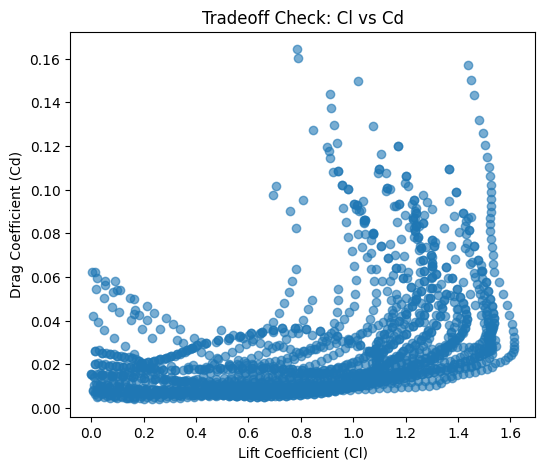

In [10]:
# =========================================
# 1. Scatter Plot
# =========================================
cl = data['coefficientLift']
cd = data['coefficientDrag']
plt.figure(figsize=(6,5))
plt.scatter(cl, cd, alpha=0.6)
plt.xlabel("Lift Coefficient (Cl)")
plt.ylabel("Drag Coefficient (Cd)")
plt.title("Tradeoff Check: Cl vs Cd")
plt.show()

In [11]:
# 2. Correlation
# =========================================
correlation = cl.corr(cd)
print("\nCorrelation between Cl and Cd:", correlation)


Correlation between Cl and Cd: 0.4399122277889315


In [6]:
# =====================================================
# 5. TRAIN / VALIDATION / TEST SPLIT
# =====================================================
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X_scaled, Y_scaled, test_size=0.3, random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

# =====================================================
# 6. BUILD SIMPLER ANN
# =====================================================
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(2)
])

model.compile(optimizer='adam', loss='mse')

c:\Users\Firdose Anjum\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# =====================================================
# 7. TRAIN
# =====================================================
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=250,
    batch_size=32,
    verbose=1
)

Epoch 1/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.7071 - val_loss: 0.3051
Epoch 2/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2432 - val_loss: 0.1642
Epoch 3/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1480 - val_loss: 0.1015
Epoch 4/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1077 - val_loss: 0.0810
Epoch 5/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0891 - val_loss: 0.0745
Epoch 6/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0779 - val_loss: 0.0657
Epoch 7/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0729 - val_loss: 0.0569
Epoch 8/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0674 - val_loss: 0.0633
Epoch 9/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0632 - val_loss: 0.0555
Epoch 10/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0596 - val_loss: 0.0492
Epoch 11/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0593 - val_loss: 0.0464
Epoch 12/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

In [8]:
Y_train_pred = model.predict(X_train)
Y_val_pred   = model.predict(X_val)
Y_test_pred  = model.predict(X_test)

# Inverse transform
Y_train_pred = scaler_Y.inverse_transform(Y_train_pred)
Y_val_pred   = scaler_Y.inverse_transform(Y_val_pred)
Y_test_pred  = scaler_Y.inverse_transform(Y_test_pred)

Y_train_true = scaler_Y.inverse_transform(Y_train)
Y_val_true   = scaler_Y.inverse_transform(Y_val)
Y_test_true  = scaler_Y.inverse_transform(Y_test)

# =====================================================
# 9. EVALUATION
# =====================================================
def evaluate(y_true, y_pred, name):
    print(f"\n{name} Results:")
    for i, output_name in enumerate(['Lift Coefficient', 'Drag Coefficient']):
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        print(f"\n{output_name}:")
        print("MSE  :", mse)
        print("RMSE :", rmse)
        print("R2   :", r2)

evaluate(Y_train_true, Y_train_pred, "Training")
evaluate(Y_val_true, Y_val_pred, "Validation")
evaluate(Y_test_true, Y_test_pred, "Testing")

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Training Results:

Lift Coefficient:
MSE  : 0.0014194814733654443
RMSE : 0.03767600660056005
R2   : 0.9928918499510972

Drag Coefficient:
MSE  : 1.3988841503669442e-05
RMSE : 0.0037401659727436484
R2   : 0.9786804106651417

Validation Results:

Lift Coefficient:
MSE  : 0.001730276689161186
RMSE : 0.0415965946822716
R2   : 0.9901296908417692

Drag Coefficient:
MSE  : 1.773143742323229e-05
RMSE : 0.0042108713377675515
R2   : 0.9724467006378215

Testing Results:

Lift Coefficient:
MSE  : 0.0018458132783638866
RMSE : 0.04296292911759959
R2   : 0.9909020875842948

Drag Coefficient:
MSE  : 1.3914434076917835e-05
RMSE : 0.003730205634669198
R2   : 0.9784576268306505


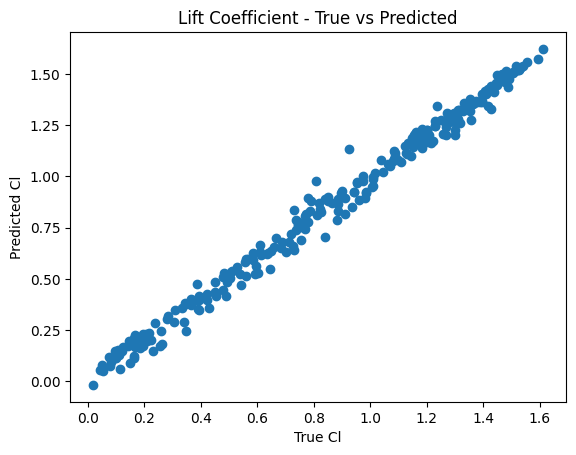

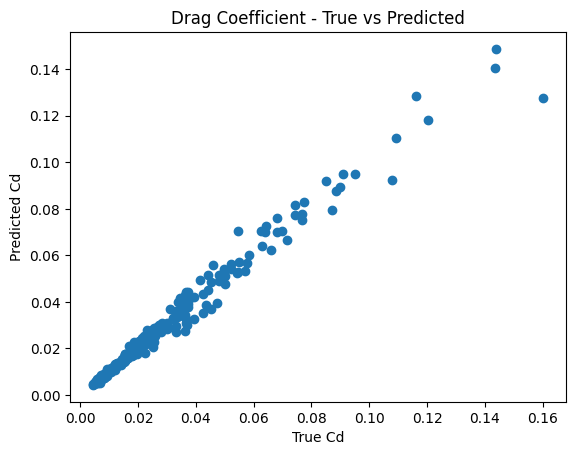

In [9]:
# 10. TRUE vs PREDICTED PLOTS
# =====================================================
plt.figure()
plt.scatter(Y_test_true[:,0], Y_test_pred[:,0])
plt.xlabel("True Cl")
plt.ylabel("Predicted Cl")
plt.title("Lift Coefficient - True vs Predicted")
plt.show()

plt.figure()
plt.scatter(Y_test_true[:,1], Y_test_pred[:,1])
plt.xlabel("True Cd")
plt.ylabel("Predicted Cd")
plt.title("Drag Coefficient - True vs Predicted")
plt.show()